In [1]:
import seaborn as sns
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

In [2]:
font = {'family': 'sans-serif',
        'color':  'black',
        'weight': 'normal',
        'size': 16,
        }

dr = '/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/d4PDF/raw/ROF/full/means'


In [3]:
'''
d4PDF land-sea mask
'''
example = xr.open_dataarray(f'{dr}/ROF_Amon_d4PDF_HPB_FullEnsMean_raw_winter_1951-2021.nc')
# d4PDF land-sea mask
lsm = xr.open_dataset('/nesi/project/niwa02986/queenle/data/d4pdf/sftlf_fx_d4PDF_HPB_m000_000000-000000.nc')
lsm = lsm.isel(time=0).drop('time')
lsm = lsm.sel(lon = slice(165,180),lat=slice(-48,-33))
lsm = lsm.interp(lat=example.lat,lon=example.lon)

/nesi/project/niwa00015/queenle/seaborn_env/lib/python3.8/site-packages/xarray/coding/times.py:152: SerializationWarning: Ambiguous reference date string: 1-1-1 00:00:00. The first value is assumed to be the year hence will be padded with zeros to remove the ambiguity (the padded reference date string is: 0001-1-1 00:00:00). To remove this message, remove the ambiguity by padding your reference date strings with zeros.
  warnings.warn(warning_msg, SerializationWarning)


In [4]:
dct = {'season':[],'type':[],'streamflow':[]}

for s in ['summer','autumn','winter','spring']:
    
    season = xr.open_dataarray(f'{dr}/ROF_Amon_d4PDF_HPB_FullEnsMean_raw_{s}_1951-2021.nc')
    
    raw = season.data.flatten()
    raw = raw[~np.isnan(raw)]
    for val in raw:
        dct['season'].append(s)
        dct['type'].append('Raw')
        dct['streamflow'].append(val)
    
    norm = (season-season.mean('time')).data.flatten()
    norm = norm[~np.isnan(norm)]
    for val in norm:
        dct['season'].append(s)
        dct['type'].append('Local mean removed')
        dct['streamflow'].append(val)


df = pd.DataFrame(dct)

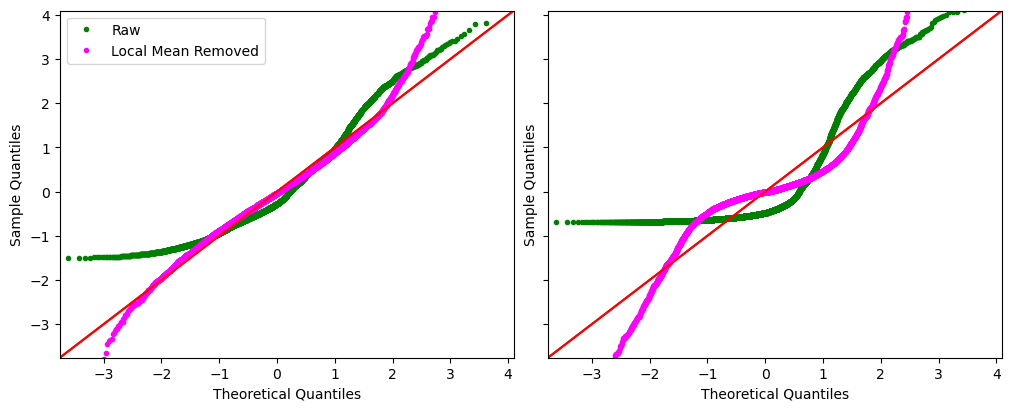

In [17]:
import statsmodels.api as sm

fig,axs = plt.subplots(1,2,figsize=(10,4),sharex=True,sharey=True,layout='constrained')

for i,s in enumerate(['winter','summer']):

    ax = axs[i]
    
    season = xr.open_dataarray(f'{dr}/ROF_Amon_d4PDF_HPB_FullEnsMean_raw_{s}_1951-2021.nc')
    
    raw = season.data.flatten()
    raw = raw[~np.isnan(raw)]

    norm = (season-season.mean('time')).data.flatten()
    norm = norm[~np.isnan(norm)]

    sm.qqplot(ax=ax,data=raw,label='Raw',line='45',fit=True,marker='.', markerfacecolor='green', markeredgecolor='green')
    sm.qqplot(ax=ax,data=norm,label='Local Mean Removed',line='45',fit=True,marker='.', markerfacecolor='magenta', markeredgecolor='magenta')

axs[0].legend()

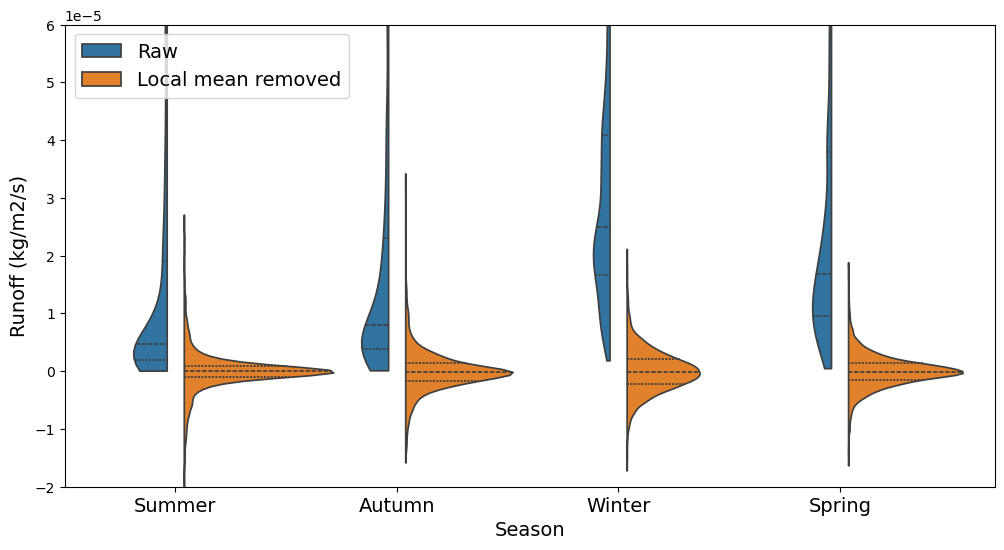

In [71]:
fig,axs = plt.subplots(figsize=(12,6))

im = sns.violinplot(ax=axs,data=df,y='streamflow',x='season',hue='type',order=['summer','autumn','winter','spring'],\
                    hue_order=['Raw','Local mean removed'],gap=.1,split=True,width=1.5,density_norm='area',orient='v',inner='quart',cut=0,common_norm=True)

axs.set_ylim(-0.00002,0.00006)
axs.set_xlim(-0.5,3.7)
axs.set_xticks([0,1,2,3],labels=['Summer','Autumn','Winter','Spring'],fontsize=14)
axs.set_xlabel('Season',fontsize=14)
axs.set_ylabel('Runoff (kg/m2/s)',fontsize=14)
axs.legend(title='',fontsize=14,loc='upper left')

plt.savefig('/home/queenle/hydro_attribution/dissertation/figures/streamflow_dist_figure.png',dpi=300)

In [65]:

locations = {'east SI':[-43.5,172],'west SI':[-44.5,168],'central NI':[-39,176],'northland':[-35.5,174]}
ys = [0,1,1.5,2]

dct = {'season':[],'type':[],'streamflow':[],'y':[],'location':[]}

for s in ['summer','autumn','winter','spring']:
    
    season = xr.open_dataarray(f'{dr}/ROF_Amon_d4PDF_HPB_FullEnsMean_raw_{s}_1951-2021.nc')

    for i,loc in enumerate(locations):
    
        ts = season.sel(lat=locations[loc][0],lon=locations[loc][1],method='nearest')
        ts_norm = (ts - ts.mean()).data.flatten()
        ts_norm = ts_norm[~np.isnan(ts_norm)]
        for val in ts_norm:
            dct['season'].append(s)
            dct['type'].append('Local mean removed')
            dct['streamflow'].append(val)
            dct['location'].append(loc)
            dct['y'].append(ys[i])

df = pd.DataFrame(dct)

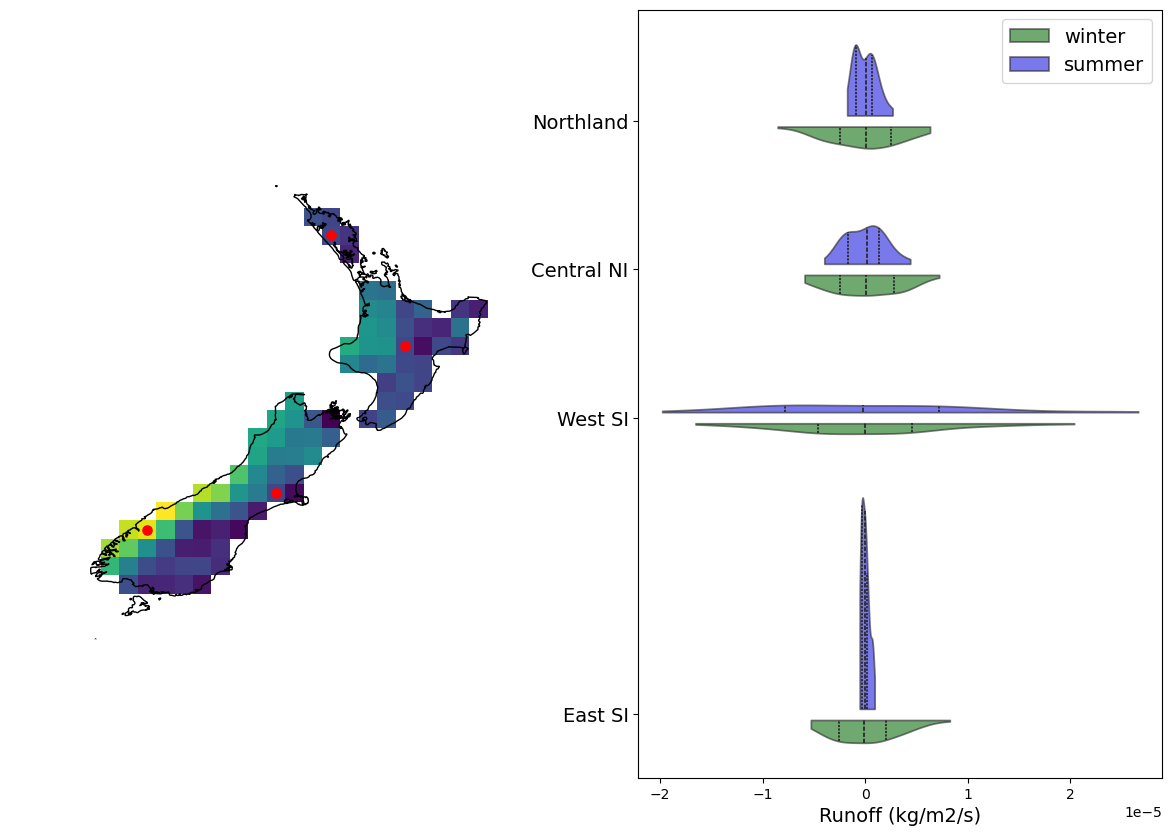

In [67]:
fig = plt.figure(figsize=(12,8))#, layout="constrained")
gs = fig.add_gridspec(1, 2)

# first axis
ax0 = fig.add_subplot(gs[0, 1])

wet_dry_df = df[df['season'].isin(['winter','summer'])]
im = sns.violinplot(ax=ax0,data=wet_dry_df,y='y',x='streamflow',hue='season',palette=['green','blue'],alpha=0.6,\
                    hue_order=['winter','summer'],gap=.05,split=True,width=3,density_norm='area',orient='h',inner='quart',common_norm=True,cut=0,native_scale=True)

ax0.set_yticks(ys,labels=['East SI','West SI','Central NI','Northland'],fontsize=14)
ax0.set_yticks(ys)
ax0.set_ylabel('',fontsize=14)
ax0.set_xlabel('Runoff (kg/m2/s)',fontsize=14)
ax0.legend(title='',fontsize=14)

# second axis
ax1 = fig.add_subplot(gs[0,0],projection=ccrs.PlateCarree())
example.isel(time=0).plot(ax=ax1,transform=ccrs.PlateCarree(),add_colorbar=False)
for loc in locations:
    ts = example.sel(lat=locations[loc][0],lon=locations[loc][1],method='nearest')
    lat = ts.lat.data
    lon = ts.lon.data
    ax1.scatter(lon,lat,color='red',s=44,transform=ccrs.PlateCarree())
    
ax1.coastlines()
ax1.set_extent([164,180, -48,-33])
ax1.set_title('')
ax1.axis('off')

plt.subplots_adjust(left=0.02, right=0.98, top=0.98, bottom=0.02,wspace=0.2, hspace=None)

plt.savefig('/home/queenle/hydro_attribution/dissertation/figures/location_dist_figure.png',dpi=300)

In [21]:
df

,x,values
0,1.6,0.933324
1,1.6,1.391117
2,1.6,2.135530
3,1.6,3.650905
4,1.6,3.998795
...,...,...
9995,23.9,15.016858
9996,23.9,14.183232
9997,23.9,15.409579
9998,23.9,14.082624


In [68]:
example

<xarray.DataArray 'rof' (time: 71, lev: 1, lat: 26, lon: 27)>
[49842 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 1951-06-01 1952-06-01 ... 2021-06-01
  * lat      (lat) float64 -47.46 -46.9 -46.33 -45.77 ... -34.54 -33.98 -33.42
  * lon      (lon) float64 165.4 165.9 166.5 167.1 ... 178.3 178.9 179.4 180.0
  * lev      (lev) float64 1e+03